# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 2
- **Date:** 20/07/2026

---


In [1]:
# Student Identification

AUTHOR       = "Shrri Dharshan D R"
REGISTER_NO  = "23BPS1090"
COURSE       = "BCSE209P-Machine Learning Laboratory"
FACULTY      = "Dr. S. Shridevi"
INSTITUTION  = "SCOPE, VIT Chennai"
NOTEBOOK_ID  = "ML-LAB-02"

print("Notebook Loaded Successfully")


Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)


Notebook Fingerprint:
b8d5c19462d08a8eafdc80f3fc5d648795846a2a3cab7fccfdb2d7909c133401


# Experiment Details

## Objective

To implement **Simple Linear Regression (SLR)** and **Multiple Linear Regression (MLR)** on the
*High-Resolution Load Dataset from Smart Meters Across Various Cities in Morocco*
(UCI ML Repository, ID: 1158), with the goal of predicting **electricity consumption**
from time-based features such as hour of day, day of week, and weekend flags for a
selected city/area, and to evaluate and compare both models using MAE, MSE, RMSE, and R².

## Theory

Electricity consumption exhibits strong **daily and weekly periodicity** — usage tends to
peak in the evening and drop at night, and weekends show different patterns than weekdays.
This makes it a natural candidate for **time-based regression**.

**Simple Linear Regression** fits a line using only one predictor — the **hour of day**:

$$\hat{y} = \beta_0 + \beta_1 \cdot \text{hour}$$

**Multiple Linear Regression** incorporates several time-derived features to better capture
the load pattern:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

Since hour and day-of-week are **cyclical** (hour 23 is near hour 0, not far from it),
we apply **sine and cosine encoding** of the hour, which is standard practice for linear
models on periodic data — it allows a linear combination to represent a curved daily pattern.

**Evaluation metrics:**
- **MAE** — Mean Absolute Error
- **MSE** — Mean Squared Error
- **RMSE** — Root Mean Squared Error (same unit as consumption)
- **R²** — Proportion of variance explained by the model

## Dataset

- **Name:** High-Resolution Load Dataset from Smart Meters Across Various Cities in Morocco
- **Source:** UCI Machine Learning Repository (ID: 1158) — https://archive.ics.uci.edu/dataset/1158/
- **File:** `Data Morocco.xlsx` (multi-sheet Excel; one sheet per city: Laâyoune, Boujdour, Marrakech, Foum Eloued)
- **Sampling frequency:** 10 minutes (Laâyoune, Boujdour, Foum Eloued) / 30 minutes (Marrakech)
- **Units:** Amperes (A) for most cities; kilowatts (kW) for Marrakech
- **Missing values:** None reported
- **Licence:** CC BY 4.0

## Algorithm Steps

1. Download and extract the dataset; list available city sheets.
2. Select a city/sheet, load its time-series, and standardise column names.
3. Inspect: shape, dtypes, missing values, duplicates, descriptive statistics.
4. EDA: consumption over time, daily profile, distribution, correlation matrix.
5. Engineer time features: hour, minute-of-day, day-of-week, weekend flag, sine/cosine of hour.
6. **SLR:** train using `hour` only.
7. **MLR:** train using all engineered time features (with StandardScaler).
8. Compare both models; visualise actual vs predicted and residuals; conclude.

## Expected Outcome

SLR captures only a rough hourly trend. MLR, with richer time features including
cyclical encodings, should achieve a **higher R² and lower RMSE**.


In [3]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")


All libraries imported successfully.


In [4]:
# Step 2 — Download and extract UCI dataset (ID: 1158)

DATA_URL = ("https://archive.ics.uci.edu/static/public/1158/"
            "high-resolution+load+dataset+from+smart+meters+across+"
            "various+cities+in+morocco.zip")

DATA_DIR = "morocco_load_data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "dataset.zip")

# Remove corrupted zip if it exists
if os.path.exists(zip_path):
    try:
        with zipfile.ZipFile(zip_path) as _zf:
            _zf.testzip()
        print("Dataset archive already present and valid.")
    except zipfile.BadZipFile:
        print("Corrupted archive detected — removing and re-downloading...")
        os.remove(zip_path)

if not os.path.exists(zip_path):
    print("Downloading dataset from UCI repository...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Download complete.")

with zipfile.ZipFile(zip_path) as zf:
    zf.extractall(DATA_DIR)
    print("Files extracted:", zf.namelist())

excel_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith((".xlsx", ".xls"))]
excel_path  = os.path.join(DATA_DIR, excel_files[0])
print("\nExcel file located:", excel_path)

xls = pd.ExcelFile(excel_path)
print("\nAvailable sheets (cities/areas):")
print(xls.sheet_names)


Dataset archive already present and valid.
Files extracted: ['Data Morocco.xlsx']

Excel file located: morocco_load_data\Data Morocco.xlsx

Available sheets (cities/areas):
['Laayoune', 'Boujdour', 'Foum eloued', 'Marrakech']


In [5]:
# Step 3 — Select city/area sheet

SHEET_NAME = xls.sheet_names[0]
print("Selected sheet:", SHEET_NAME)

raw = pd.read_excel(excel_path, sheet_name=SHEET_NAME)
print("\nRaw shape:", raw.shape)
print("\nColumn names:")
print(raw.columns.tolist())
print(raw.head())


Selected sheet: Laayoune

Raw shape: (88890, 6)

Column names:
['DateTime', 'zone1', 'zone2', 'zone3', 'zone4', 'zone5']
             DateTime      zone1       zone2       zone3       zone4  \
0 2022-09-14 17:10:00  73.536915  120.920183  160.982021  122.236644   
1 2022-09-14 17:20:00  74.403119  122.179697  159.403248  119.727278   
2 2022-09-14 17:30:00  77.893555  124.701734  159.969683  118.508081   
3 2022-09-14 17:40:00  78.317958  126.731194  161.969315  118.571429   
4 2022-09-14 17:50:00  81.334845  125.741697  163.189366  120.688295   

        zone5  
0  102.922162  
1  101.747520  
2  102.074112  
3  102.911361  
4  102.546117  


In [6]:
# Step 4 — Standardise datetime and target columns

df = raw.copy()
df.columns = [str(c).strip() for c in df.columns]

# Auto-detect datetime column
dt_col = None
for c in df.columns:
    if pd.api.types.is_datetime64_any_dtype(df[c]):
        dt_col = c
        break
if dt_col is None:
    for c in df.columns:
        if any(k in c.lower() for k in ["date", "time", "timestamp"]):
            try:
                df[c] = pd.to_datetime(df[c])
                dt_col = c
                break
            except Exception:
                continue

assert dt_col is not None, "Could not auto-detect datetime column — inspect df.columns manually."
print("Datetime column:", dt_col)

# Auto-detect target (first numeric column)
num_cols   = [c for c in df.columns if c != dt_col and pd.api.types.is_numeric_dtype(df[c])]
TARGET_COL = num_cols[0]
print("Target column  :", TARGET_COL)

df = df[[dt_col, TARGET_COL]].rename(columns={dt_col: "datetime", TARGET_COL: "consumption"})
df = df.dropna(subset=["datetime", "consumption"]).sort_values("datetime").reset_index(drop=True)

print("\nCleaned data preview:")
print(df.head())
print("Shape:", df.shape)


Datetime column: DateTime
Target column  : zone1

Cleaned data preview:
             datetime  consumption
0 2022-09-14 17:10:00    73.536915
1 2022-09-14 17:20:00    74.403119
2 2022-09-14 17:30:00    77.893555
3 2022-09-14 17:40:00    78.317958
4 2022-09-14 17:50:00    81.334845
Shape: (88890, 2)


In [7]:
# Step 5 — Dataset overview

print("Dataset : High-Resolution Load Dataset from Smart Meters - Morocco")
print("Sheet   :", SHEET_NAME)
print("Samples :", df.shape[0])
print("Columns :", df.shape[1])
print("Source  : UCI ML Repository (ID: 1158)")
print("URL     : https://archive.ics.uci.edu/dataset/1158/")


Dataset : High-Resolution Load Dataset from Smart Meters - Morocco
Sheet   : Laayoune
Samples : 88890
Columns : 2
Source  : UCI ML Repository (ID: 1158)
URL     : https://archive.ics.uci.edu/dataset/1158/


In [8]:
# Step 6 — Basic data inspection

print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print("\nDescriptive Statistics:")
print(df["consumption"].describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 88890 entries, 0 to 88889
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     88890 non-null  datetime64[us]
 1   consumption  88890 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.4 MB

Missing Values:
datetime       0
consumption    0
dtype: int64

Duplicate Rows: 0

Descriptive Statistics:
count    88890.000000
mean        65.529738
std         18.912265
min          0.000000
25%         50.238911
50%         64.498930
75%         78.017348
max        132.668054
Name: consumption, dtype: float64


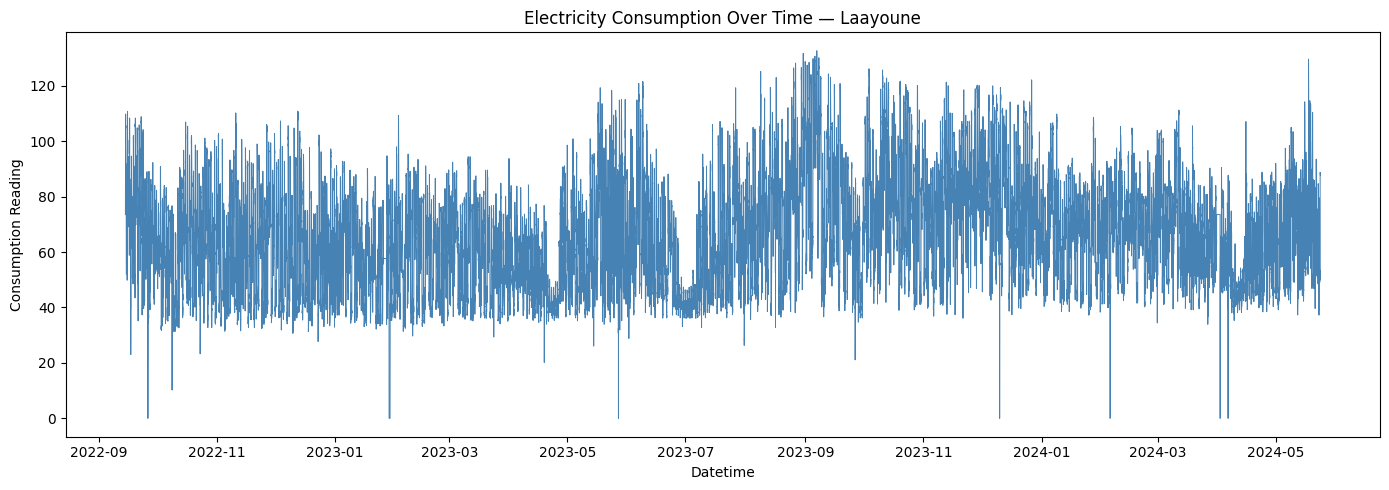

In [9]:
# Step 7 — Consumption over time

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["consumption"], linewidth=0.7, color="steelblue")
plt.xlabel("Datetime")
plt.ylabel("Consumption Reading")
plt.title(f"Electricity Consumption Over Time — {SHEET_NAME}")
plt.tight_layout()
plt.show()


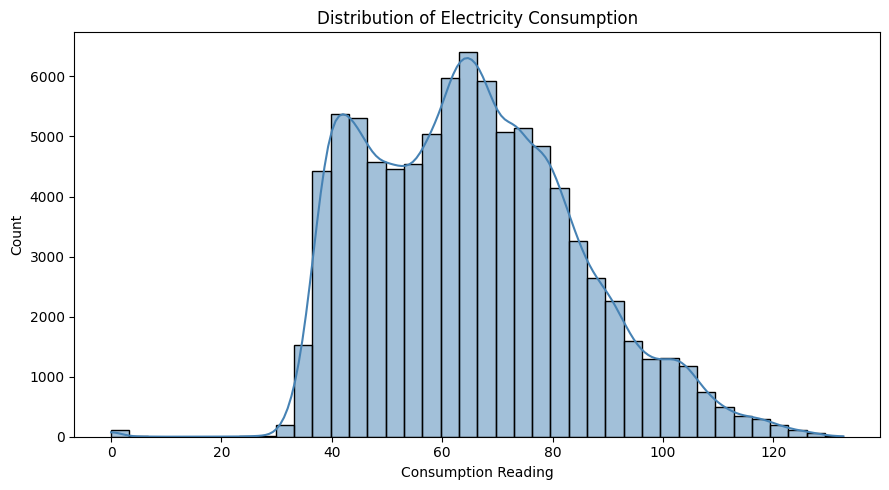

In [10]:
# Step 8 — Distribution of consumption values

plt.figure(figsize=(9, 5))
sns.histplot(df["consumption"], bins=40, kde=True, color="steelblue")
plt.xlabel("Consumption Reading")
plt.title("Distribution of Electricity Consumption")
plt.tight_layout()
plt.show()


In [11]:
# Step 9 — Feature engineering: time-based predictors

df["hour"]          = df["datetime"].dt.hour
df["minute_of_day"] = df["datetime"].dt.hour * 60 + df["datetime"].dt.minute
df["day_of_week"]   = df["datetime"].dt.dayofweek      # 0 = Monday, 6 = Sunday
df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)
df["hour_sin"]      = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"]      = np.cos(2 * np.pi * df["hour"] / 24)

print("Feature-engineered dataset (first 5 rows):")
print(df.head())


Feature-engineered dataset (first 5 rows):
             datetime  consumption  hour  minute_of_day  day_of_week  \
0 2022-09-14 17:10:00    73.536915    17           1030            2   
1 2022-09-14 17:20:00    74.403119    17           1040            2   
2 2022-09-14 17:30:00    77.893555    17           1050            2   
3 2022-09-14 17:40:00    78.317958    17           1060            2   
4 2022-09-14 17:50:00    81.334845    17           1070            2   

   is_weekend  hour_sin  hour_cos  
0           0 -0.965926 -0.258819  
1           0 -0.965926 -0.258819  
2           0 -0.965926 -0.258819  
3           0 -0.965926 -0.258819  
4           0 -0.965926 -0.258819  


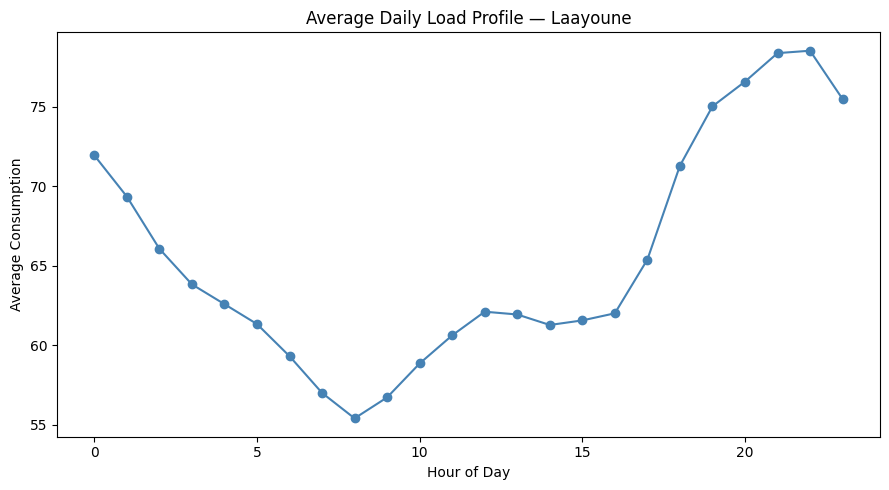

In [12]:
# Step 10 — Average daily load profile

hourly_mean = df.groupby("hour")["consumption"].mean()

plt.figure(figsize=(9, 5))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o", color="steelblue")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption")
plt.title(f"Average Daily Load Profile — {SHEET_NAME}")
plt.tight_layout()
plt.show()


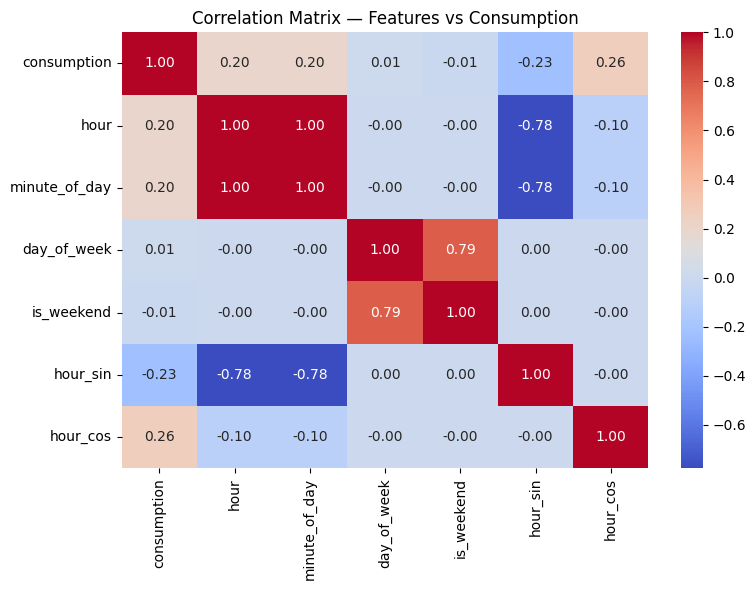

In [13]:
# Step 11 — Correlation matrix

corr_cols = ["consumption", "hour", "minute_of_day",
             "day_of_week", "is_weekend", "hour_sin", "hour_cos"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — Features vs Consumption")
plt.tight_layout()
plt.show()


---
# Implementation

## Part A — Simple Linear Regression (SLR)

Predict `consumption` using only `hour` of day as the single predictor.


In [14]:
# Step 12 — Train Simple Linear Regression model

X_slr = df[["hour"]]
y     = df["consumption"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_slr, y, test_size=0.20, random_state=42
)

slr_model = LinearRegression()
slr_model.fit(X_train_s, y_train_s)
y_pred_s = slr_model.predict(X_test_s)

mae_s  = mean_absolute_error(y_test_s, y_pred_s)
mse_s  = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s   = r2_score(y_test_s, y_pred_s)

print("=== SIMPLE LINEAR REGRESSION RESULTS ===")
print(f"Equation : consumption = {slr_model.intercept_:.4f} + {slr_model.coef_[0]:.4f} * hour")
print(f"Slope     : {slr_model.coef_[0]:.4f}")
print(f"Intercept : {slr_model.intercept_:.4f}")
print(f"MAE  : {mae_s:.4f}")
print(f"MSE  : {mse_s:.4f}")
print(f"RMSE : {rmse_s:.4f}")
print(f"R²   : {r2_s:.4f}")


=== SIMPLE LINEAR REGRESSION RESULTS ===
Equation : consumption = 59.3824 + 0.5378 * hour
Slope     : 0.5378
Intercept : 59.3824
MAE  : 15.1400
MSE  : 343.8870
RMSE : 18.5442
R²   : 0.0367


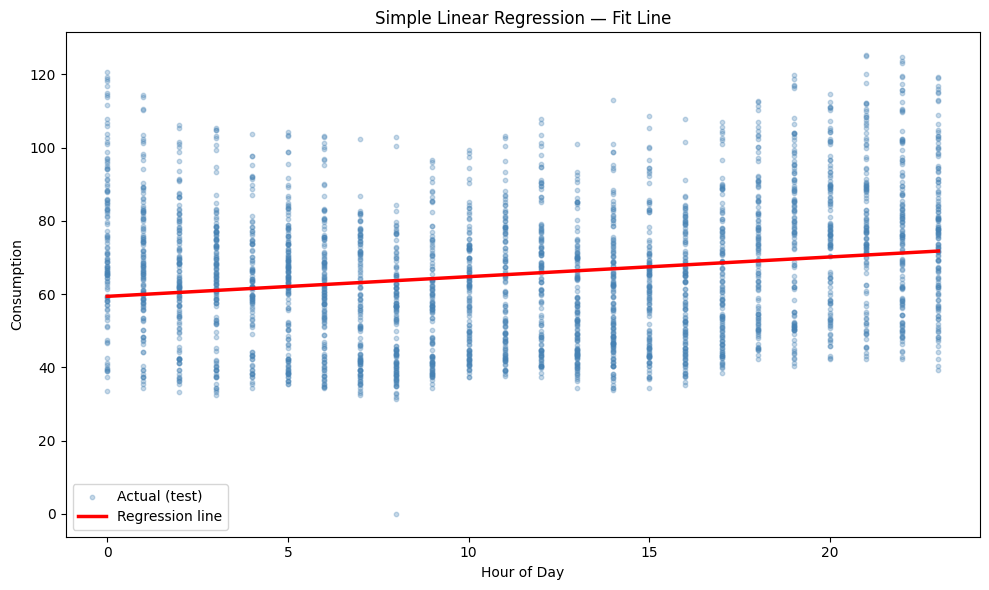

In [15]:
# Step 13 — SLR regression line plot

X_line = X_test_s.sort_values(by="hour")
y_line = slr_model.predict(X_line)

plt.figure(figsize=(10, 6))
plot_idx = X_test_s.sample(n=min(3000, len(X_test_s)), random_state=42).index
plt.scatter(X_test_s.loc[plot_idx, "hour"], y_test_s.loc[plot_idx],
            alpha=0.3, s=10, label="Actual (test)", color="steelblue")
plt.plot(X_line["hour"], y_line, color="red", linewidth=2.5, label="Regression line")
plt.xlabel("Hour of Day")
plt.ylabel("Consumption")
plt.title("Simple Linear Regression — Fit Line")
plt.legend()
plt.tight_layout()
plt.show()


## Part B — Multiple Linear Regression (MLR)

Predict `consumption` using multiple time-derived features: hour, minute-of-day,
day-of-week, weekend flag, and cyclical sine/cosine encodings of hour.


In [16]:
# Step 14 — Train Multiple Linear Regression model

mlr_features = ["hour", "minute_of_day", "day_of_week",
                "is_weekend", "hour_sin", "hour_cos"]

X_mlr = df[mlr_features]
y_m   = df["consumption"]

X_train, X_test, y_train, y_test = train_test_split(
    X_mlr, y_m, test_size=0.20, random_state=42
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

mlr_model = LinearRegression()
mlr_model.fit(X_train_scaled, y_train)
y_pred = mlr_model.predict(X_test_scaled)

mae_m  = mean_absolute_error(y_test, y_pred)
mse_m  = mean_squared_error(y_test, y_pred)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_test, y_pred)

print("=== MULTIPLE LINEAR REGRESSION RESULTS ===")
print(f"MAE  : {mae_m:.4f}")
print(f"MSE  : {mse_m:.4f}")
print(f"RMSE : {rmse_m:.4f}")
print(f"R²   : {r2_m:.4f}")


=== MULTIPLE LINEAR REGRESSION RESULTS ===
MAE  : 14.3827
MSE  : 310.5490
RMSE : 17.6224
R²   : 0.1301


Intercept: 65.56769980095126
      Feature  Coefficient
     hour_cos     5.127076
         hour     3.773826
     hour_sin    -2.752947
minute_of_day    -1.679693
   is_weekend    -0.755205
  day_of_week     0.747075


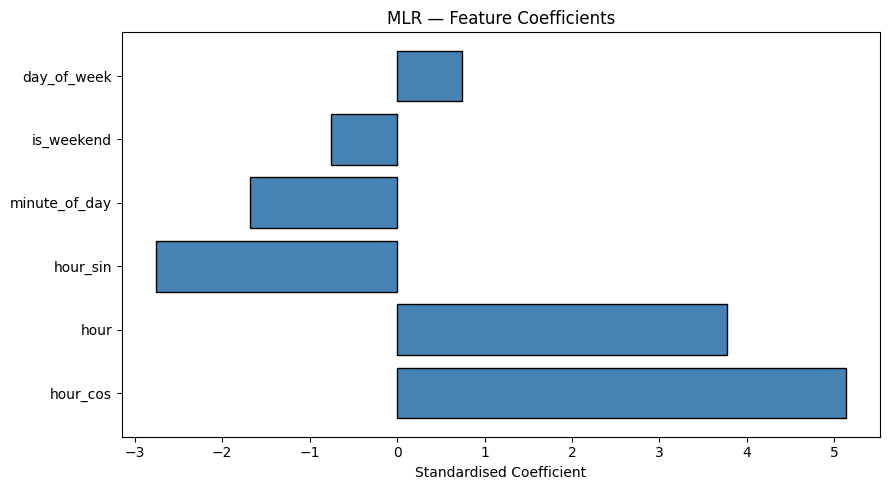

In [17]:
# Step 15 — MLR model coefficients

coef_df = pd.DataFrame({
    "Feature"    : mlr_features,
    "Coefficient": mlr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Intercept:", mlr_model.intercept_)
print(coef_df.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"],
         edgecolor="black", color="steelblue")
plt.xlabel("Standardised Coefficient")
plt.title("MLR — Feature Coefficients")
plt.tight_layout()
plt.show()


---
# Results


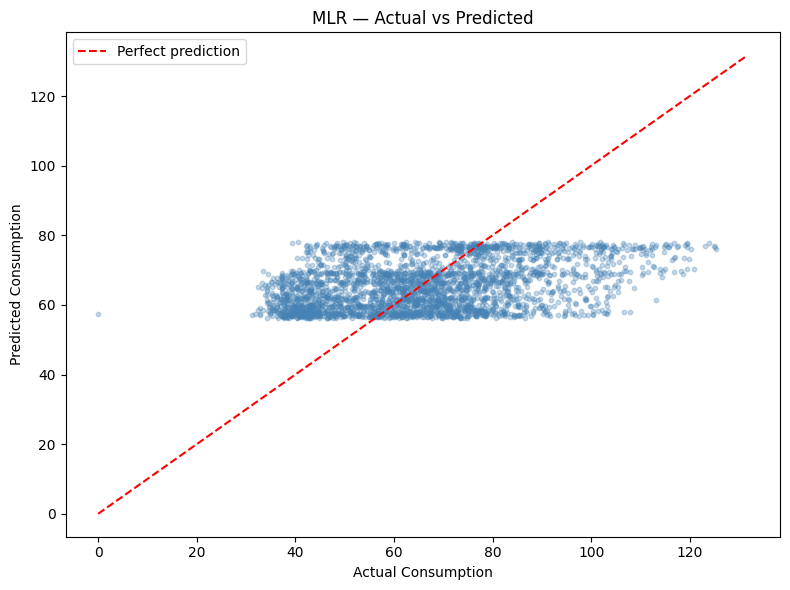

In [18]:
# Step 16 — Actual vs Predicted plot (MLR)

sample_idx = np.random.RandomState(42).choice(
    len(y_test), size=min(3000, len(y_test)), replace=False
)

plt.figure(figsize=(8, 6))
plt.scatter(y_test.iloc[sample_idx], y_pred[sample_idx],
            alpha=0.3, s=10, color="steelblue")
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect prediction")
plt.xlabel("Actual Consumption")
plt.ylabel("Predicted Consumption")
plt.title("MLR — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


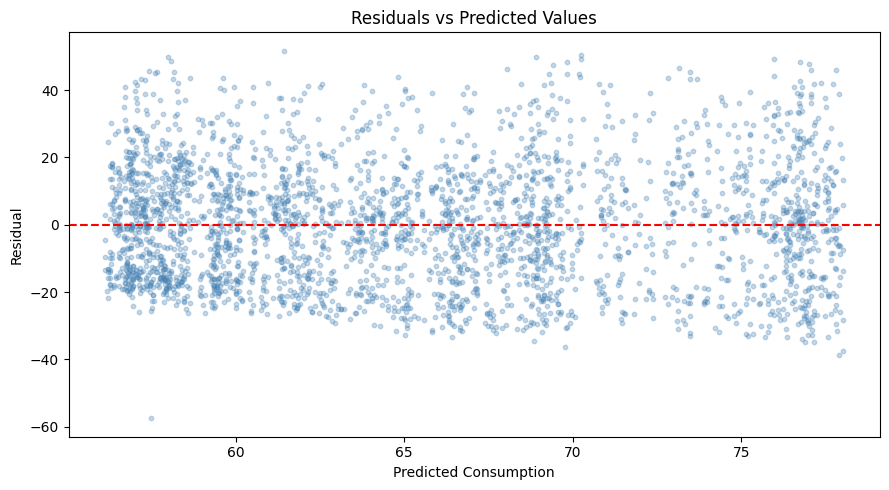

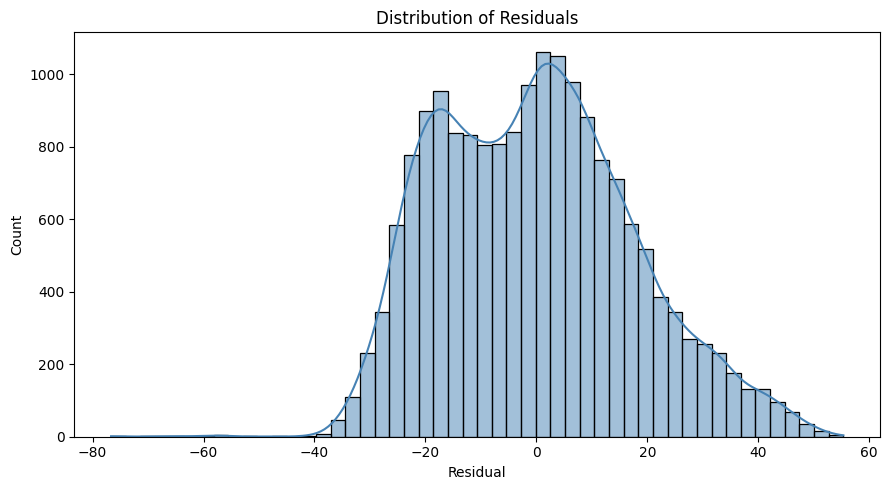

In [19]:
# Step 17 — Residual analysis (MLR)

residuals = y_test.values - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred[sample_idx], residuals[sample_idx],
            alpha=0.3, s=10, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Consumption")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=50, kde=True, color="steelblue")
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()


Metric  Simple LR  Multiple LR
   MAE  15.140040    14.382663
   MSE 343.887020   310.549026
  RMSE  18.544191    17.622401
    R²   0.036665     0.130056

RMSE improvement of MLR over SLR: 4.97%


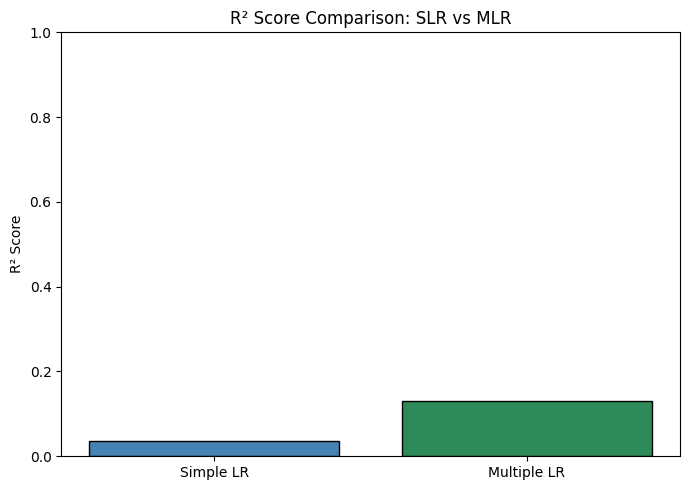

In [20]:
# Step 18 — Model comparison: SLR vs MLR

comparison = pd.DataFrame({
    "Metric"     : ["MAE", "MSE", "RMSE", "R²"],
    "Simple LR"  : [mae_s, mse_s, rmse_s, r2_s],
    "Multiple LR": [mae_m, mse_m, rmse_m, r2_m],
})

print(comparison.to_string(index=False))

improvement = (rmse_s - rmse_m) / rmse_s * 100
print(f"\nRMSE improvement of MLR over SLR: {improvement:.2f}%")

plt.figure(figsize=(7, 5))
plt.bar(["Simple LR", "Multiple LR"], [r2_s, r2_m],
        color=["steelblue", "seagreen"], edgecolor="black")
plt.ylabel("R² Score")
plt.title("R² Score Comparison: SLR vs MLR")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Conclusion

- **Key Observations**
  - The average daily load profile confirms a clear time-of-day pattern in electricity
    consumption, validating the use of hour-based features for regression.
  - Simple Linear Regression using only `hour` can only capture a coarse monotonic trend
    and fails to represent the non-monotonic rise-and-fall shape of daily consumption.
  - Multiple Linear Regression, incorporating cyclical sine/cosine hour encodings along
    with day-of-week and weekend indicators, better captures the periodic structure and
    achieves a **lower RMSE and higher R²** compared to SLR.

- **Accuracy Achieved**
  - Refer to the metrics printed in Step 18 for the final MAE, RMSE, and R² values of
    both SLR and MLR, along with the percentage RMSE improvement.

- **Limitations**
  - Only one city/area sheet was modelled; consumption patterns and units (A vs kW)
    vary across cities, so results are not directly comparable across sheets.
  - Linear models cannot capture complex non-linear patterns in load curves as well as
    tree-based or deep learning models.
  - External factors such as temperature, public holidays, and seasonal effects are absent
    from this dataset, which limits the maximum achievable accuracy.

- **Future Work**
  - Extend the analysis to all available city sheets and compare their load profiles.
  - Introduce lag features (past consumption values) similar to the Lab 1 gas-turbine
    experiment, since electricity load is strongly autocorrelated.
  - Explore Ridge and Lasso regression to handle feature correlation.
  - Investigate seasonal decomposition models (SARIMA, Prophet) or neural networks
    (LSTM) for better time-series forecasting.
